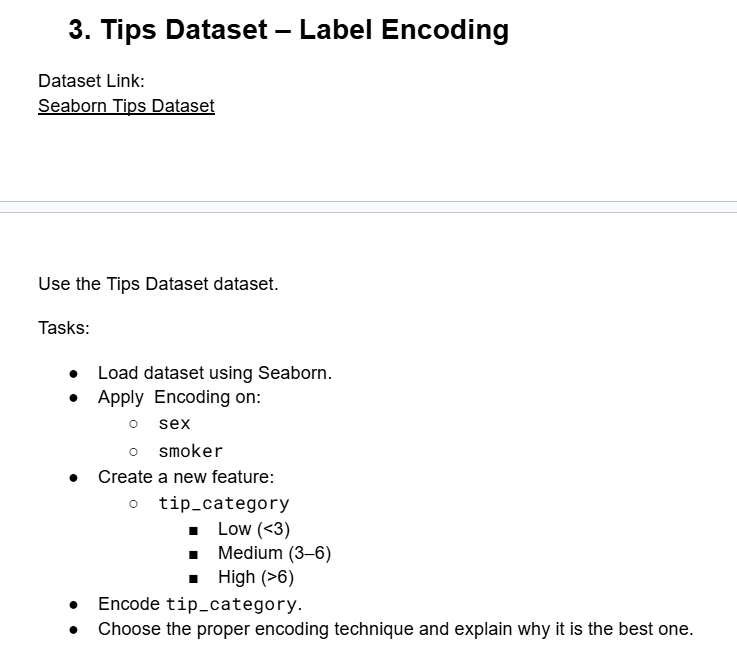

In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder

In [8]:
df = sns.load_dataset("tips")
df

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [11]:
ohe = OneHotEncoder(sparse_output=False).set_output(transform="pandas")

encoded_df = ohe.fit_transform(df[["sex", "smoker"]])

df = pd.concat([df, encoded_df], axis=1)

df = df.drop(["sex", "smoker"], axis=1)

In [12]:
df["tip_category"] = np.where(df["tip"] < 3, "Low", np.where(df["tip"] <= 6, "Medium", "High"))

df[["tip", "tip_category"]].head()

,tip,tip_category
0,1.01,Low
1,1.66,Low
2,3.50,Medium
3,3.31,Medium
4,3.61,Medium


In [13]:
ohe = OneHotEncoder(sparse_output=False).set_output(transform="pandas")

tip_encoded = ohe.fit_transform(df[["tip_category"]])

df = pd.concat([df, tip_encoded], axis=1)

df = df.drop("tip_category", axis=1)

df.head()

,total_bill,tip,day,time,size,sex_Female,sex_Male,smoker_No,smoker_Yes,tip_category_High,tip_category_Low,tip_category_Medium
0,16.99,1.01,Sun,Dinner,2,1.0,0.0,1.0,0.0,0.0,1.0,0.0
1,10.34,1.66,Sun,Dinner,3,0.0,1.0,1.0,0.0,0.0,1.0,0.0
2,21.01,3.50,Sun,Dinner,3,0.0,1.0,1.0,0.0,0.0,0.0,1.0
3,23.68,3.31,Sun,Dinner,2,0.0,1.0,1.0,0.0,0.0,0.0,1.0
4,24.59,3.61,Sun,Dinner,4,1.0,0.0,1.0,0.0,0.0,0.0,1.0
